In [1]:
# Gradient Accumulation
#
# 1. 언제 / 왜 사용하는가?
# - GPU VRAM이 부족해서 원하는 큰 Batch size를 한 번에 올릴 수 없을 때 사용
# - 원하는 batch size >> 실제 가능한 batch size X로 축소해서 X개씩 Y번 forward/backward
# - optimizer.step()은 1번만!
#
# - Batch size와 peak VRAM 관계, 얻는 이점과 단점
#   - forward때 나온 정보들을 backward 계산용으로 전부 저장해야함. 그래서 batch size가 커질수록 peak VRAM 부담이 커지는 것.
#   - 연산량을 줄이는게 아니고 순간 필요한 최대 메모리 부담을 줄이는 것.
#   - 큰 GPU 없이도 학습이 가능한 점에서는 싸게 학습이 가능하다고 할 수 있다.
#   - But (1) 속도 저하 (2) GPU는 큰 batch가 효율적 (3) 각종 문제
#   - Foundation model은 GA로 해결할 정도의 규모가 아님. 많이 사용되지만 보조 기술 중 하나.
#
# 2. Loss를 Y로 나누는 이유
# - loss.backward()를 Y번 하게되면 gradient가 Y번 합쳐지기 때문에
#   아무 처리 없이 accumulation하면 gradient ≈ 기존의 Y배
#   실질적인 update 크기 증가 ≈ learning rate가 커진 효과
#   loss = loss / accumulation_steps(Y)
# - LR을 1/4해버리는건?
#   - 수학적으로는 어느 정도 상쇄될 수 있겠지만
#     gradient magnitude 자체가 커진 상태는 그대로라서 clipping, AMP 안정성, optimizer 내부 통계 등에 영향을 줄 수 있다.
#
# 3. Gradient accumulation은 gradient만 누적하지 BatchNorm 통계를 누적하지는 않는다.
#    BN은 축소한 batch size = X를 기준으로 동작하기 때문에 실제 원래 batch size와 완전히 동일하지 않을 수 있다.
#  - 해결책
#    1. BN 대신 LayerNorm / GroupNorm 사용
#    2. BN momentum 조정
#    3. batch size 너무 작지 않게 유지
#
# 4. LR Scheduler를 사용하면 optimizer update는 기존 횟수 / Y 번만 발생한다.
#    기존의 의도한 LR 감소 속도보다 4배 빨라질 수 있기 때문.
# - 해결책: optimizer.step()이 실제 수행될 때만 sheduler.step()을 하도록 맞춘다.
#
# 5. edge device에서 자원 사용량을 줄이는거라기 보다는 자원 부담을 분산시키는 것에 가깝다.
#    총 연산량은 오히려 약간 늘어날 수도 있다. (foward/backward 여러번)
# - "아예 계산 자체를 덜 하자" (X), "계산량은 유지하되 메모리를 나눠 쓰자" (O)
# - 그리고 Inference는 backward 자체를 하지 않기 때문에 GA는 직접적으로 영향이 있는게 아님. (trainning 전용 기법)
#
#
# | 기법                   | 목적
# | --------------------- | ---------------------
# | Gradient Accumulation | 메모리 부담 분산
# | Early Exit            | 연산량 감소
# | Quantization          | 모델/연산 경량화
# | Pruning               | 불필요 계산 제거
# | Dynamic Routing       | 어려운 샘플만 깊게 계산

In [ ]:
# | Case                | 목적
# | ------------------- | -----------------------------------
# | `B64_ACC1`          | 진짜 batch 64 기준
# | `B16_ACC4_scaled`   | GA 정상 적용
# | `B16_ACC4_unscaled` | loss 안 나눴을 때 grad norm 증가 관찰

Device: cuda
Experiment        : BS512
Batch size        : 512
Accum steps       : 1
Effective batch   : 512
Scale loss        : True
[BS512] Epoch 01/30 | Train Loss 1.1163 | Test Loss 0.6281 | Acc 0.7733 | Macro-F1 0.7551 | GradNorm 3.1538 | Updates 15 | Time 3.41s | Peak VRAM 5294.3MB
[BS512] Epoch 10/30 | Train Loss 0.1114 | Test Loss 0.2259 | Acc 0.9213 | Macro-F1 0.9218 | GradNorm 0.4479 | Updates 15 | Time 1.55s | Peak VRAM 5294.3MB
[BS512] Epoch 20/30 | Train Loss 0.0750 | Test Loss 0.3169 | Acc 0.9332 | Macro-F1 0.9330 | GradNorm 0.5026 | Updates 15 | Time 1.55s | Peak VRAM 5294.3MB
[BS512] Epoch 30/30 | Train Loss 0.0336 | Test Loss 0.3303 | Acc 0.9243 | Macro-F1 0.9253 | GradNorm 0.4277 | Updates 15 | Time 1.56s | Peak VRAM 5294.3MB

Classification Report
              precision    recall  f1-score   support

        WALK     1.0000    0.9355    0.9667       496
          UP     0.9872    0.9851    0.9862       471
        DOWN     0.9167    0.9952    0.9543       420
      

,Experiment,Final Acc,Final Macro-F1,Best Epoch,Best Acc,Best Macro-F1,Final Train Loss,Final Test Loss,Avg Epoch Time,Final Grad Norm,Peak VRAM MB,Updates per Epoch
0,BS512,0.924330,0.925306,15,0.943672,0.945027,0.033565,0.330284,1.618699,0.427678,5294.251465,15.0
1,BS128x4,0.944350,0.944822,21,0.949779,0.949935,0.006519,0.291672,1.698888,0.206530,1370.113281,15.0
2,BS128x4-w/o_scale_loss,0.946725,0.946895,21,0.950797,0.950766,0.002833,0.289263,1.705701,0.394014,1378.021484,15.0


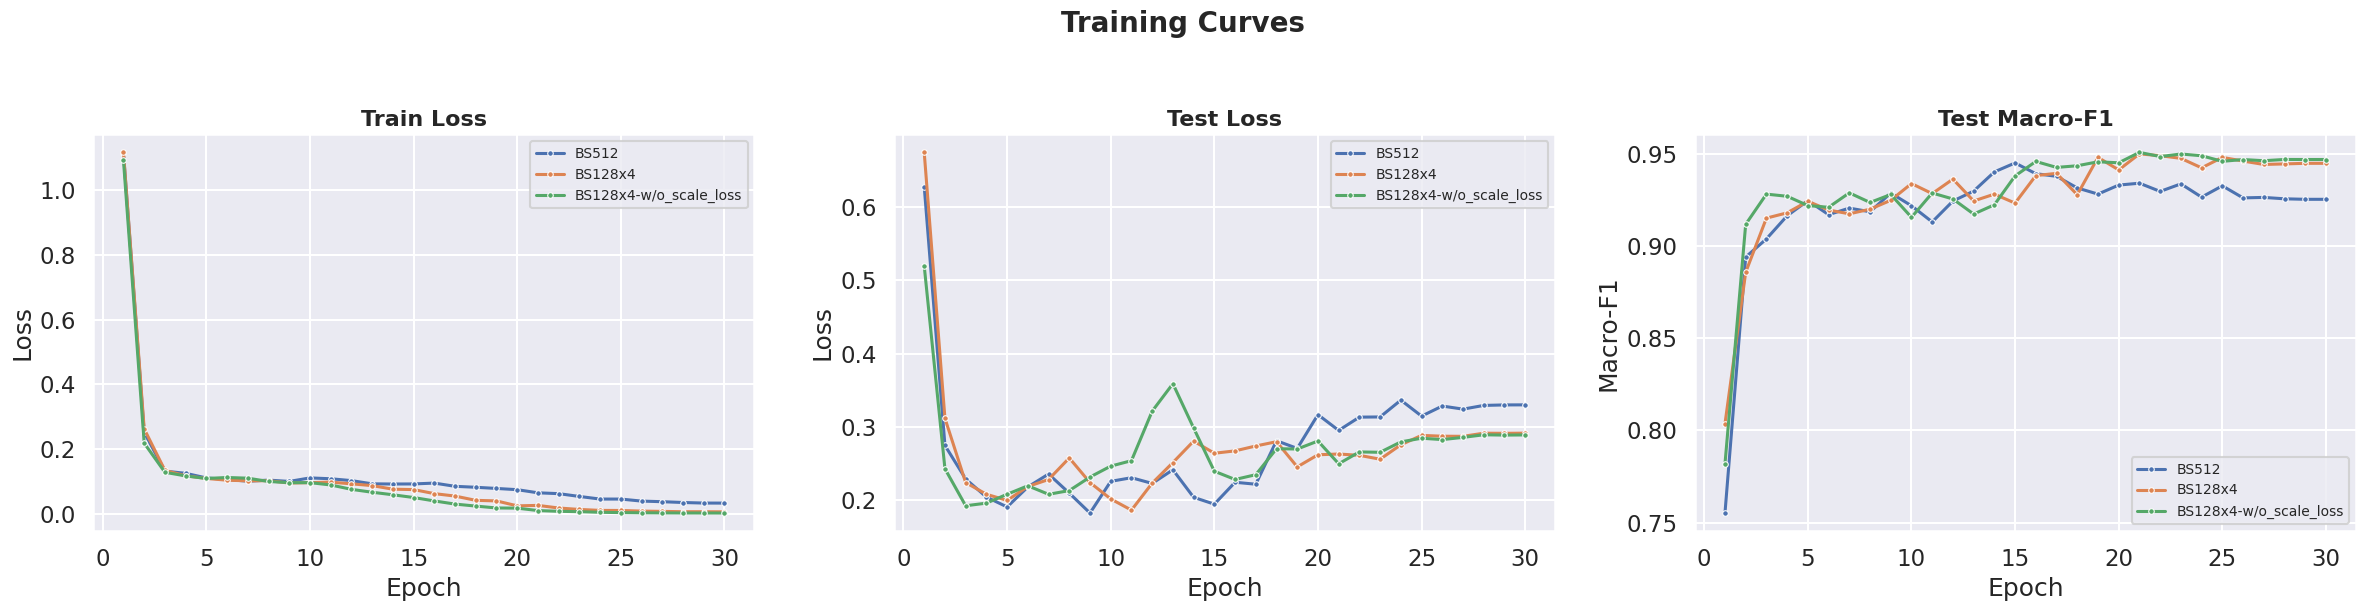

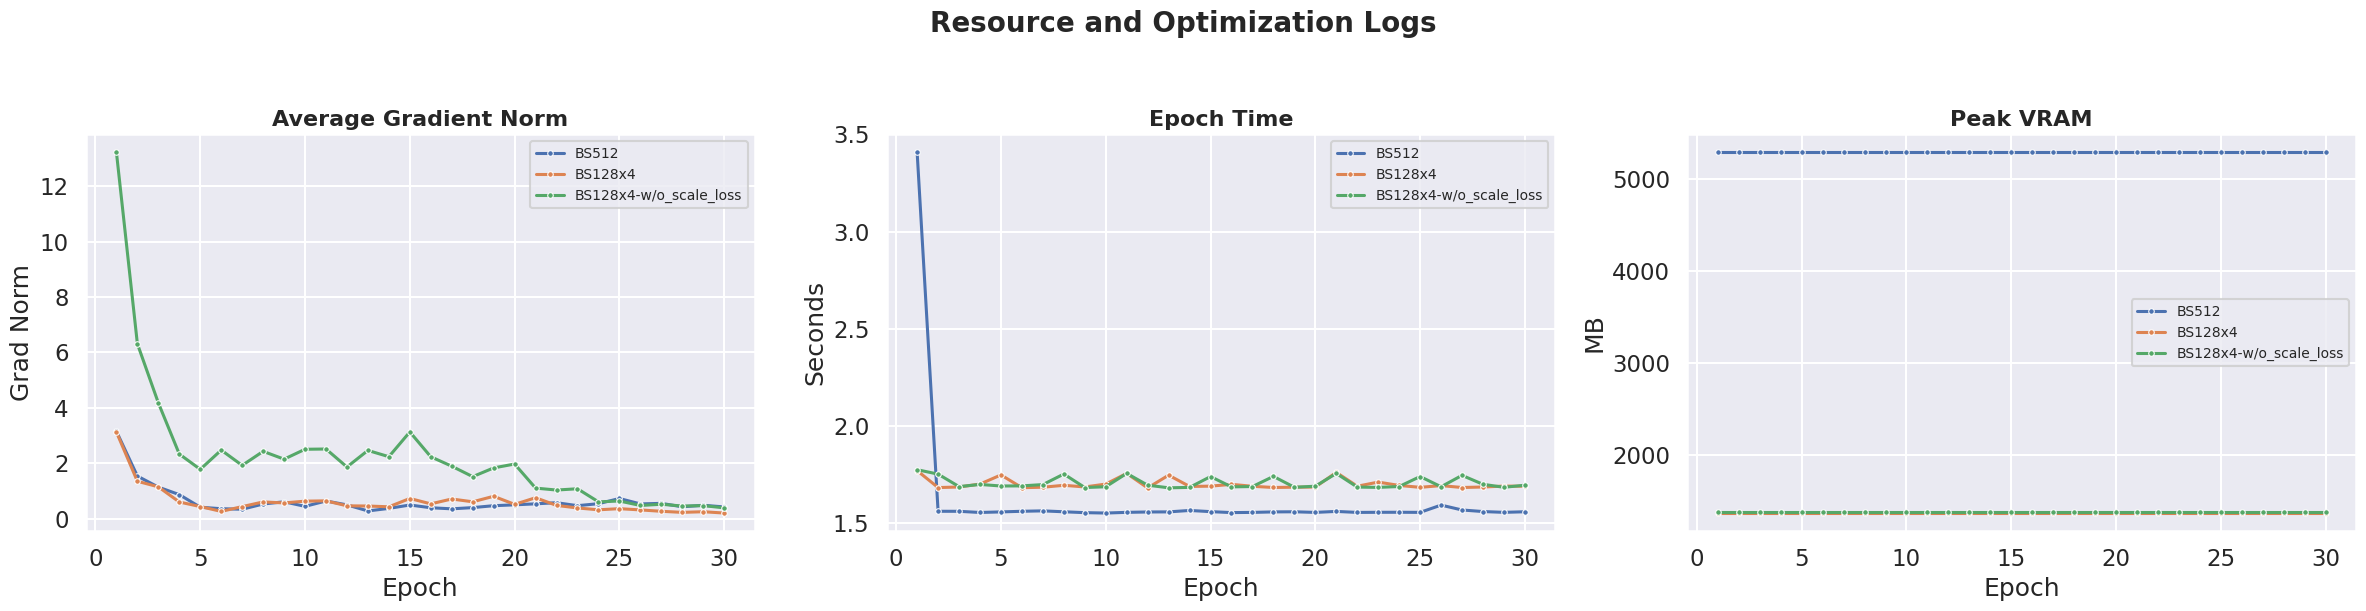

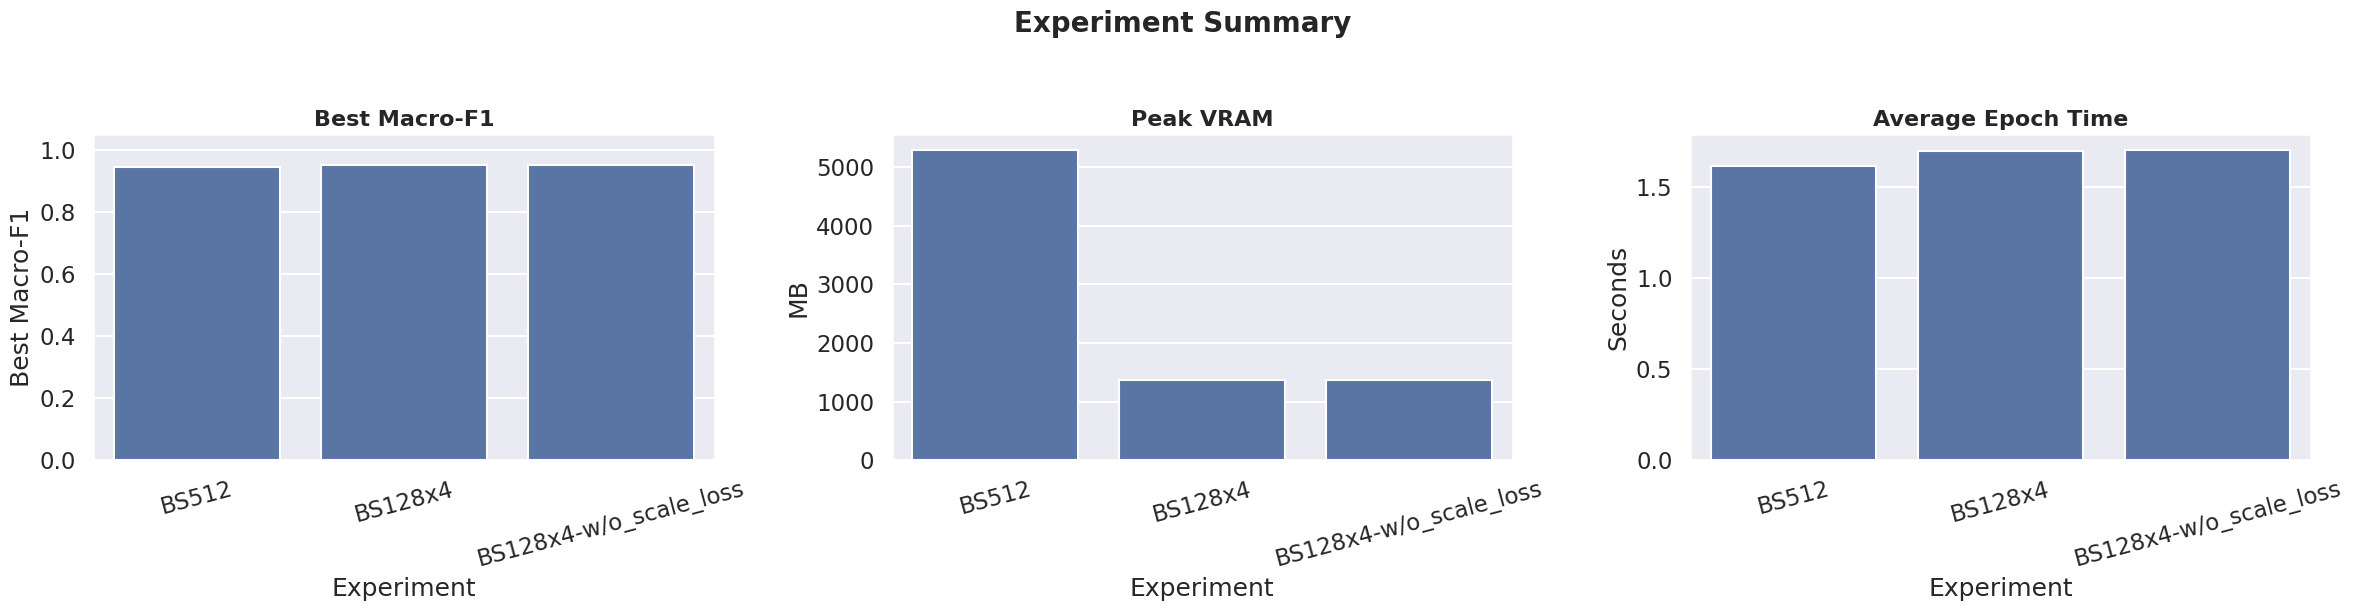

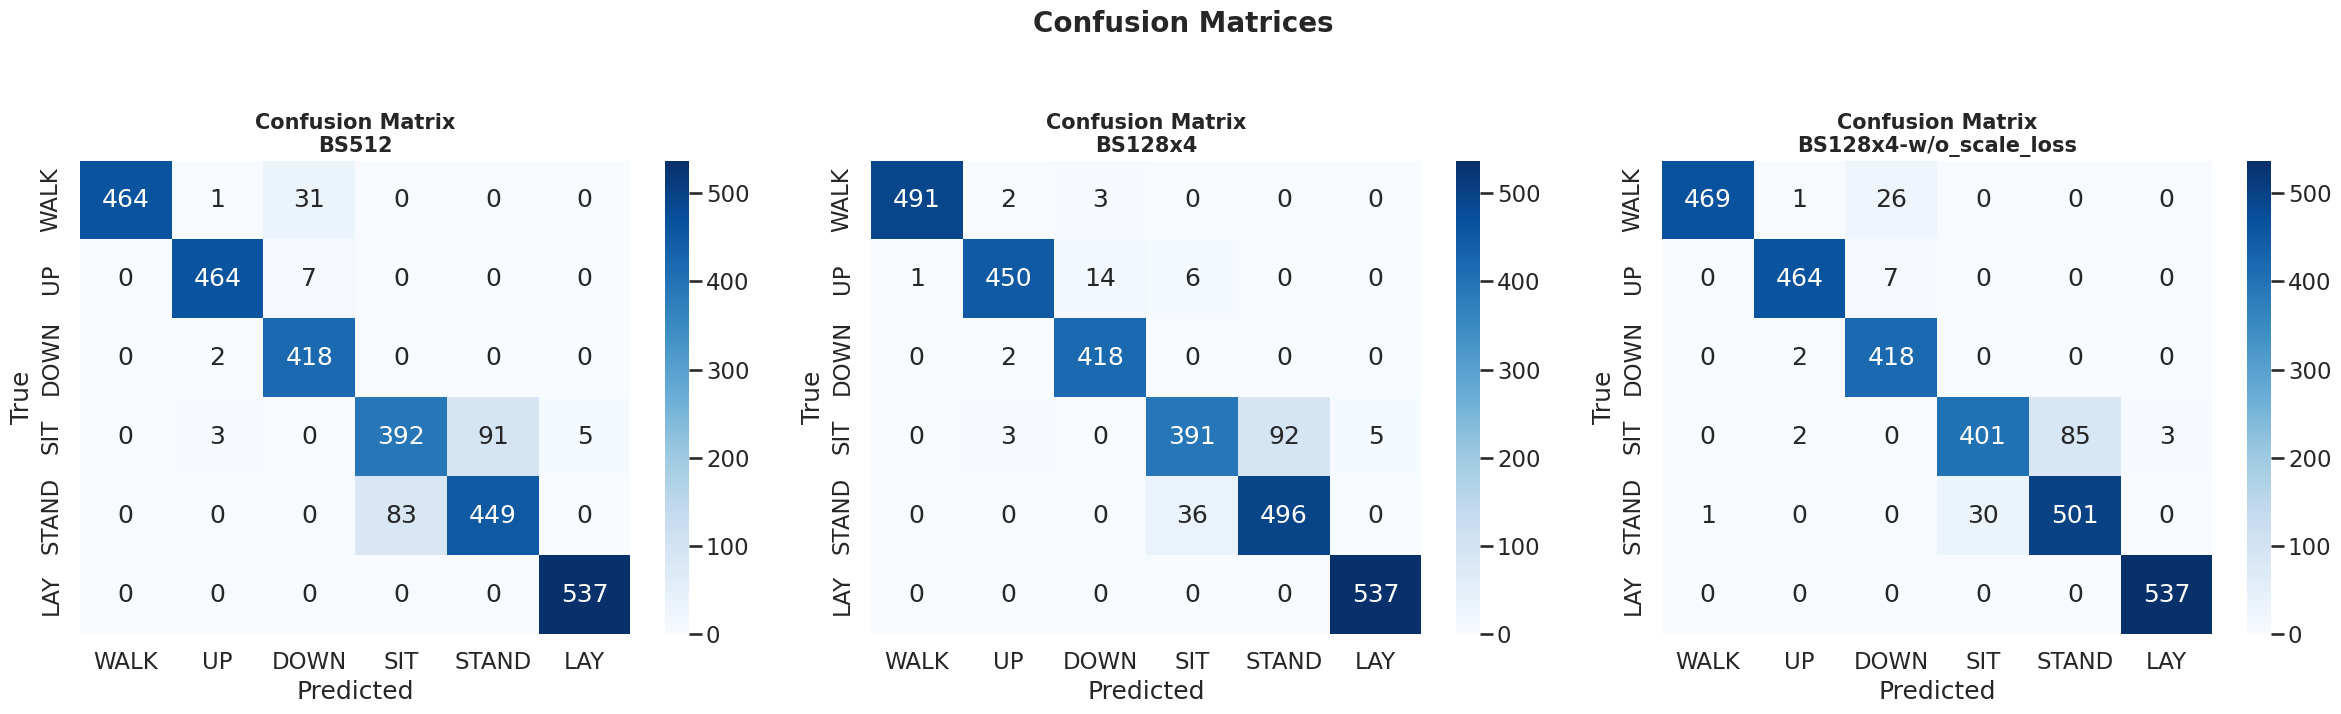

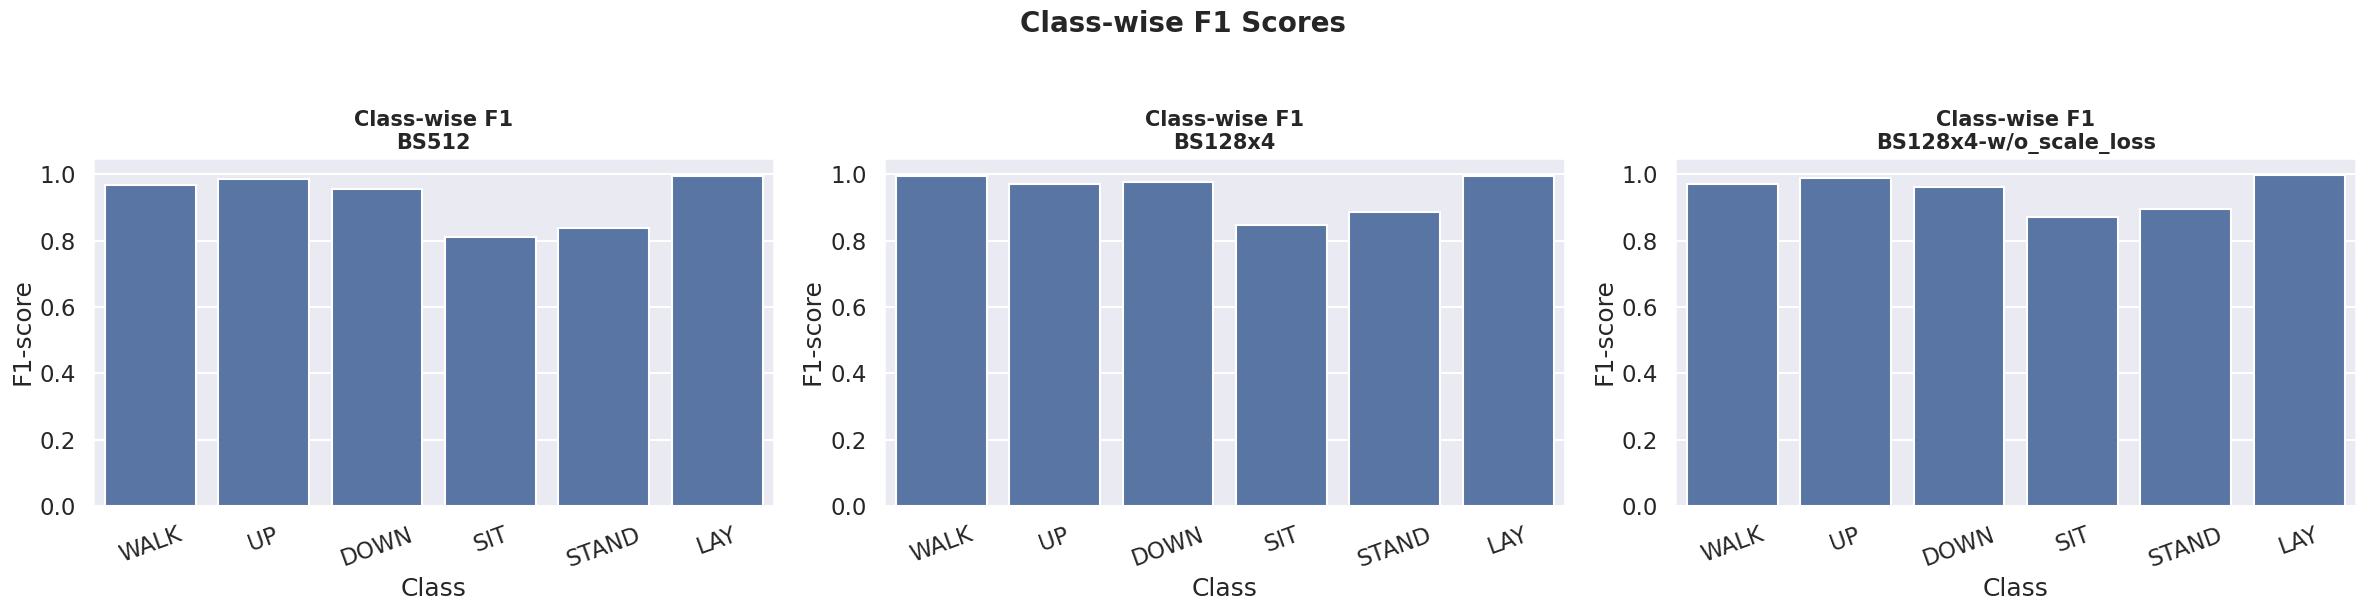

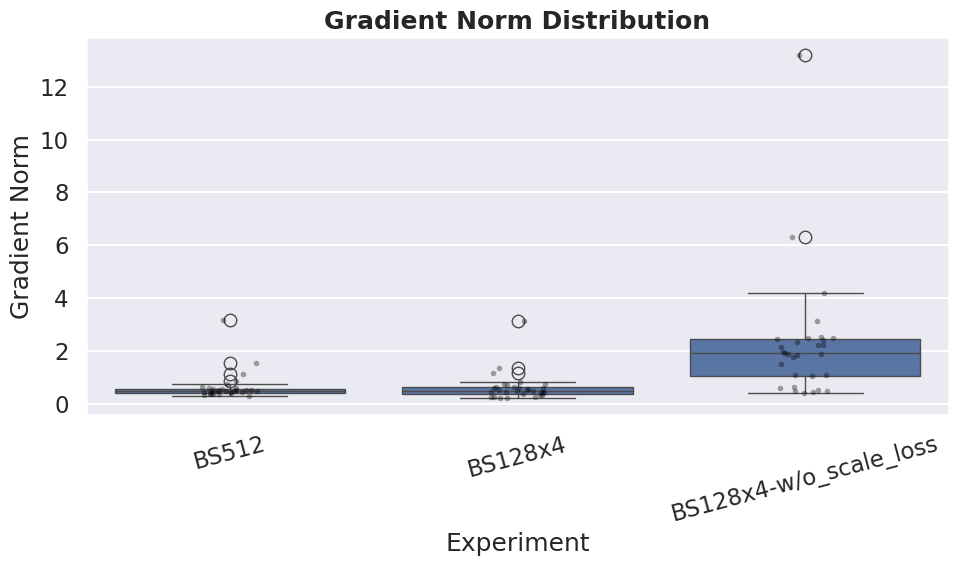

In [1]:
# ============================================================
# 0. Imports
# ============================================================
import os
import time
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

sns.set_theme(style="darkgrid", context="talk")

# ============================================================
# 1. Config
# ============================================================
SEED = 42
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/datasets/UCI-HAR"

CLASS_NAMES = ["WALK", "UP", "DOWN", "SIT", "STAND", "LAY"]

EPOCHS = 30
LR = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 5.0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)

print("Device:", DEVICE)

# ============================================================
# 2. Dataset
# ============================================================
class UCIHARDataset(Dataset):
    def __init__(self, data_dir, split="train", normalize=None):
        self.data_dir = Path(data_dir)
        self.split = split
        self.X, self.y = self._load_data()
        self.X = torch.FloatTensor(self.X)
        self.y = torch.LongTensor(self.y) - 1
        self.normalize = normalize

    def _load_data(self):
        split_dir = self.data_dir / self.split

        signal_types = [
            "body_acc_x", "body_acc_y", "body_acc_z",
            "body_gyro_x", "body_gyro_y", "body_gyro_z",
            "total_acc_x", "total_acc_y", "total_acc_z",
        ]

        signals = []

        for st in signal_types:
            fname = split_dir / "Inertial Signals" / f"{st}_{self.split}.txt"
            signals.append(np.loadtxt(fname))

        X = np.stack(signals, axis=1)
        y = np.loadtxt(split_dir / f"y_{self.split}.txt", dtype=int)

        return X, y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        X = self.X[idx]
        y = self.y[idx]

        if self.normalize is not None:
            mean, std = self.normalize
            X = (X - mean.squeeze(0)) / std.squeeze(0)

        return X, y


# train-only normalization
tmp_train = UCIHARDataset(DATA_DIR, split="train", normalize=None)
train_mean = tmp_train.X.mean(dim=(0, 2), keepdim=True)
train_std = tmp_train.X.std(dim=(0, 2), keepdim=True) + 1e-6
NORMALIZE = (train_mean, train_std)

# ============================================================
# 3. PADRe Components without Gate
# ============================================================
class PADReBlockNoGate(nn.Module):
    def __init__(
        self,
        channels,
        seq_len,
        max_degree=3,
        token_kernel=11,
    ):
        super().__init__()

        self.max_degree = max_degree

        self.channel_mixing = nn.ModuleList([
            nn.Conv1d(channels, channels, kernel_size=1)
            for _ in range(max_degree)
        ])

        self.token_mixing = nn.ModuleList([
            nn.Conv1d(
                channels,
                channels,
                kernel_size=token_kernel,
                padding=token_kernel // 2,
                groups=channels
            )
            for _ in range(max_degree)
        ])

        self.pre_hadamard_channel = nn.ModuleList([
            nn.Conv1d(channels, channels, kernel_size=1)
            for _ in range(max_degree - 1)
        ])

        self.pre_hadamard_token = nn.ModuleList([
            nn.Conv1d(
                channels,
                channels,
                kernel_size=token_kernel,
                padding=token_kernel // 2,
                groups=channels
            )
            for _ in range(max_degree - 1)
        ])

        self.norm = nn.LayerNorm(channels)

    def _build_Z(self, x):
        Y = [
            self.token_mixing[i](self.channel_mixing[i](x))
            for i in range(self.max_degree)
        ]

        Z = [Y[0]]

        for i in range(1, self.max_degree):
            Z_prev = self.pre_hadamard_token[i - 1](
                self.pre_hadamard_channel[i - 1](Z[-1])
            )
            Z.append(Z_prev * Y[i])

        return Z

    def forward(self, x):
        Z = self._build_Z(x)

        # gate 제거: 항상 최고 degree 출력 사용
        out = Z[-1]

        out = self.norm(out.permute(0, 2, 1)).permute(0, 2, 1)

        return out


class PADReHARClassifier(nn.Module):
    def __init__(
        self,
        in_channels=9,
        seq_len=128,
        hidden_dim=256,
        num_classes=6,
        num_blocks=6,
        max_degree=3,
        dropout=0.1,
    ):
        super().__init__()

        self.input_proj = nn.Conv1d(in_channels, hidden_dim, kernel_size=1)

        self.blocks = nn.ModuleList([
            PADReBlockNoGate(
                channels=hidden_dim,
                seq_len=seq_len,
                max_degree=max_degree,
                token_kernel=11,
            )
            for _ in range(num_blocks)
        ])

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: [B, C, T]
        z = self.input_proj(x)

        for block in self.blocks:
            z = block(z)

        z = z.mean(dim=-1)
        z = self.dropout(z)

        logits = self.classifier(z)

        return logits

# ============================================================
# 4. Utility
# ============================================================
def get_grad_norm(model):
    total_norm = 0.0

    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.detach().data.norm(2)
            total_norm += param_norm.item() ** 2

    return total_norm ** 0.5


@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    all_y = []
    all_pred = []
    total_loss = 0.0

    criterion = nn.CrossEntropyLoss()

    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        logits = model(x)
        loss = criterion(logits, y)

        pred = logits.argmax(dim=1)

        total_loss += loss.item() * x.size(0)
        all_y.extend(y.cpu().numpy())
        all_pred.extend(pred.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_y, all_pred)
    macro_f1 = f1_score(all_y, all_pred, average="macro")

    return avg_loss, acc, macro_f1, np.array(all_y), np.array(all_pred)


def train_one_experiment(
    exp_name,
    batch_size,
    accum_steps,
    scale_loss=True,
    lr=LR,
):
    print("=" * 80)
    print(f"Experiment        : {exp_name}")
    print(f"Batch size        : {batch_size}")
    print(f"Accum steps       : {accum_steps}")
    print(f"Effective batch   : {batch_size * accum_steps}")
    print(f"Scale loss        : {scale_loss}")
    print("=" * 80)

    set_seed(SEED)

    train_ds = UCIHARDataset(DATA_DIR, split="train", normalize=NORMALIZE)
    test_ds = UCIHARDataset(DATA_DIR, split="test", normalize=NORMALIZE)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
        num_workers=2,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=512,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    model = PADReHARClassifier(
        in_channels=9,
        seq_len=128,
        hidden_dim=256,
        num_classes=6,
        num_blocks=6,
        max_degree=3,
        dropout=0.1,
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS
    )

    history = defaultdict(list)

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    for epoch in range(1, EPOCHS + 1):
        model.train()

        start_time = time.time()

        running_loss = 0.0
        update_count = 0
        grad_norm_list = []

        optimizer.zero_grad(set_to_none=True)

        for step, (x, y) in enumerate(train_loader):
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            logits = model(x)
            loss = criterion(logits, y)

            loss_for_backward = loss / accum_steps if scale_loss else loss
            loss_for_backward.backward()

            running_loss += loss.item() * x.size(0)

            do_update = (
                ((step + 1) % accum_steps == 0)
                or ((step + 1) == len(train_loader))
            )

            if do_update:
                grad_norm = get_grad_norm(model)
                grad_norm_list.append(grad_norm)

                if GRAD_CLIP is not None:
                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(),
                        GRAD_CLIP
                    )

                optimizer.step()
                optimizer.zero_grad(set_to_none=True)

                update_count += 1

        scheduler.step()

        epoch_time = time.time() - start_time

        train_loss = running_loss / len(train_loader.dataset)
        test_loss, test_acc, test_macro_f1, y_true, y_pred = evaluate(
            model,
            test_loader
        )

        if torch.cuda.is_available():
            peak_vram = torch.cuda.max_memory_allocated() / 1024 ** 2
        else:
            peak_vram = 0.0

        avg_grad_norm = (
            float(np.mean(grad_norm_list))
            if len(grad_norm_list) > 0
            else 0.0
        )

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["test_macro_f1"].append(test_macro_f1)
        history["epoch_time"].append(epoch_time)
        history["avg_grad_norm"].append(avg_grad_norm)
        history["update_count"].append(update_count)
        history["peak_vram_mb"].append(peak_vram)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        # 10 epoch마다 + 1 epoch + 마지막 epoch만 출력
        if (epoch == 1) or (epoch % 10 == 0) or (epoch == EPOCHS):
            print(
                f"[{exp_name}] "
                f"Epoch {epoch:02d}/{EPOCHS} | "
                f"Train Loss {train_loss:.4f} | "
                f"Test Loss {test_loss:.4f} | "
                f"Acc {test_acc:.4f} | "
                f"Macro-F1 {test_macro_f1:.4f} | "
                f"GradNorm {avg_grad_norm:.4f} | "
                f"Updates {update_count} | "
                f"Time {epoch_time:.2f}s | "
                f"Peak VRAM {peak_vram:.1f}MB"
            )

    print("\nClassification Report")
    print(classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4
    ))

    result = {
        "exp_name": exp_name,
        "history": pd.DataFrame(history),
        "y_true": y_true,
        "y_pred": y_pred,
        "model": model,
    }

    return result

# ============================================================
# 5. Run Experiments
# ============================================================
experiments = []

experiments.append(
    train_one_experiment(
        exp_name="BS512",
        batch_size=512,
        accum_steps=1,
        scale_loss=True,
        lr=LR,
    )
)

experiments.append(
    train_one_experiment(
        exp_name="BS128x4",
        batch_size=128,
        accum_steps=4,
        scale_loss=True,
        lr=LR,
    )
)

experiments.append(
    train_one_experiment(
        exp_name="BS128x4-w/o_scale_loss",
        batch_size=128,
        accum_steps=4,
        scale_loss=False,
        lr=LR,
    )
)

# ============================================================
# 6. Summary Table
# ============================================================
summary_rows = []

for res in experiments:
    h = res["history"]

    last = h.iloc[-1]
    best_idx = h["test_macro_f1"].idxmax()
    best = h.loc[best_idx]

    summary_rows.append({
        "Experiment": res["exp_name"],

        "Final Acc": last["test_acc"],
        "Final Macro-F1": last["test_macro_f1"],

        "Best Epoch": int(best["epoch"]),
        "Best Acc": best["test_acc"],
        "Best Macro-F1": best["test_macro_f1"],

        "Final Train Loss": last["train_loss"],
        "Final Test Loss": last["test_loss"],

        "Avg Epoch Time": h["epoch_time"].mean(),
        "Final Grad Norm": last["avg_grad_norm"],
        "Peak VRAM MB": h["peak_vram_mb"].max(),
        "Updates per Epoch": last["update_count"],
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

# ============================================================
# 7. Training Log Visualization: subplots (1, 3)
# ============================================================
def plot_metric_group(experiments, metrics, titles, ylabels, suptitle):
    fig, axes = plt.subplots(1, 3, figsize=(24, 6))

    for ax, metric, title, ylabel in zip(axes, metrics, titles, ylabels):
        for res in experiments:
            h = res["history"]

            sns.lineplot(
                ax=ax,
                data=h,
                x="epoch",
                y=metric,
                linewidth=2.2,
                marker="o",
                markersize=4,
                label=res["exp_name"]
            )

        ax.set_title(title, fontsize=16, weight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.legend(frameon=True, fontsize=10)

    fig.suptitle(suptitle, fontsize=20, weight="bold", y=1.03)
    plt.tight_layout()
    plt.show()


plot_metric_group(
    experiments,
    metrics=["train_loss", "test_loss", "test_macro_f1"],
    titles=["Train Loss", "Test Loss", "Test Macro-F1"],
    ylabels=["Loss", "Loss", "Macro-F1"],
    suptitle="Training Curves"
)

plot_metric_group(
    experiments,
    metrics=["avg_grad_norm", "epoch_time", "peak_vram_mb"],
    titles=["Average Gradient Norm", "Epoch Time", "Peak VRAM"],
    ylabels=["Grad Norm", "Seconds", "MB"],
    suptitle="Resource and Optimization Logs"
)

# ============================================================
# 8. Summary Visualization: subplots (1, 3)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

sns.barplot(
    ax=axes[0],
    data=summary_df,
    x="Experiment",
    y="Best Macro-F1"
)
axes[0].set_title("Best Macro-F1", fontsize=16, weight="bold")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(
    ax=axes[1],
    data=summary_df,
    x="Experiment",
    y="Peak VRAM MB"
)
axes[1].set_title("Peak VRAM", fontsize=16, weight="bold")
axes[1].set_ylabel("MB")
axes[1].tick_params(axis="x", rotation=15)

sns.barplot(
    ax=axes[2],
    data=summary_df,
    x="Experiment",
    y="Avg Epoch Time"
)
axes[2].set_title("Average Epoch Time", fontsize=16, weight="bold")
axes[2].set_ylabel("Seconds")
axes[2].tick_params(axis="x", rotation=15)

fig.suptitle("Experiment Summary", fontsize=20, weight="bold", y=1.03)
plt.tight_layout()
plt.show()

# ============================================================
# 9. Confusion Matrix: subplots (1, 3)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, res in zip(axes, experiments):
    cm = confusion_matrix(res["y_true"], res["y_pred"])

    sns.heatmap(
        cm,
        ax=ax,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        cbar=True
    )

    ax.set_title(
        f"Confusion Matrix\n{res['exp_name']}",
        fontsize=15,
        weight="bold"
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

fig.suptitle("Confusion Matrices", fontsize=20, weight="bold", y=1.03)
plt.tight_layout()
plt.show()

# ============================================================
# 10. Class-wise F1: subplots (1, 3)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

for ax, res in zip(axes, experiments):
    report_dict = classification_report(
        res["y_true"],
        res["y_pred"],
        target_names=CLASS_NAMES,
        output_dict=True,
        digits=4
    )

    class_f1 = pd.DataFrame({
        "Class": CLASS_NAMES,
        "F1-score": [
            report_dict[c]["f1-score"]
            for c in CLASS_NAMES
        ]
    })

    sns.barplot(
        ax=ax,
        data=class_f1,
        x="Class",
        y="F1-score"
    )

    ax.set_ylim(0, 1.05)
    ax.set_title(
        f"Class-wise F1\n{res['exp_name']}",
        fontsize=15,
        weight="bold"
    )
    ax.set_xlabel("Class")
    ax.set_ylabel("F1-score")
    ax.tick_params(axis="x", rotation=20)

fig.suptitle("Class-wise F1 Scores", fontsize=20, weight="bold", y=1.03)
plt.tight_layout()
plt.show()

# ============================================================
# 11. Gradient Norm Distribution
# ============================================================
grad_df = []

for res in experiments:
    h = res["history"]

    for v in h["avg_grad_norm"]:
        grad_df.append({
            "Experiment": res["exp_name"],
            "GradNorm": v
        })

grad_df = pd.DataFrame(grad_df)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=grad_df,
    x="Experiment",
    y="GradNorm"
)

sns.stripplot(
    data=grad_df,
    x="Experiment",
    y="GradNorm",
    color="black",
    alpha=0.35,
    size=4
)

plt.title("Gradient Norm Distribution", fontsize=18, weight="bold")
plt.xlabel("Experiment")
plt.ylabel("Gradient Norm")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()